In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Problem Statement:

You are tasked with predicting the trip price of a taxi ride based on various factors such as the distance traveled, time of day, day of the week, traffic conditions, weather conditions, and the base fare structure. The dataset includes the following features:

- Distance traveled (in km): The distance the taxi travels during the ride.
- Time of day: The time of day when the trip was initiated (e.g., Morning, Afternoon, Evening, Night).
- Day of the week: Whether the trip took place on a weekday or weekend.
- Passenger count: The number of passengers in the taxi.
- Traffic conditions: The level of traffic during the ride (e.g., Low, Medium, High).
- Weather: The weather conditions during the ride (e.g., Clear, Rain).
- Base fare: The starting fare for the taxi ride.
- Per km rate: The fare rate charged per kilometer traveled.
- Per minute rate: The fare rate charged per minute of the ride.
- Trip duration (in minutes): The total duration of the taxi ride.

**Goal:**
- Build a regression model that can accurately predict the trip price based on the above features. The model should handle missing values, categorical data (e.g., time of day, weather, traffic conditions), and numerical data (e.g., distance, base fare).

**Expected Outcome**:
- The trained model should be able to predict the taxi fare for a given ride, which can assist in fare estimation tools or help the company optimize pricing strategies based on various factors influencing the fare.



In [2]:
df = pd.read_csv(r"C:\Users\SHRI\OneDrive\Desktop\DataScience_DataFiles\ML_data\taxi_trip_pricing.csv")

In [3]:
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


# Data Understanding

In [4]:
df.shape

(1000, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


# Data Exploration on raw data


In [6]:
df.columns.tolist()

['Trip_Distance_km',
 'Time_of_Day',
 'Day_of_Week',
 'Passenger_Count',
 'Traffic_Conditions',
 'Weather',
 'Base_Fare',
 'Per_Km_Rate',
 'Per_Minute_Rate',
 'Trip_Duration_Minutes',
 'Trip_Price']

- All columns are given in correct syntax

In [7]:
df.dtypes

Trip_Distance_km         float64
Time_of_Day               object
Day_of_Week               object
Passenger_Count          float64
Traffic_Conditions        object
Weather                   object
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object

- All data types given in the correct dtype excet passenger_count convert it to int

In [8]:
# Missing Values not convert to int so convert it to int64
df['Passenger_Count'] = df['Passenger_Count'].astype('Int64')


In [9]:
df.dtypes

Trip_Distance_km         float64
Time_of_Day               object
Day_of_Week               object
Passenger_Count            Int64
Traffic_Conditions        object
Weather                   object
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object

- All datatypes is in correct format

In [10]:
for i in df :
    print(i, " : ", df[i].unique())
    print("===================================")

Trip_Distance_km  :  [ 19.35        47.59        36.87        30.33                nan
   8.64         3.85        43.44        30.45        35.7
  48.53        41.79        11.4          9.91         9.99
  15.91        26.71        22.17        15.27        30.98
   7.84       105.94355004  18.95        23.35        39.47
  10.78       138.09832791  30.03         3.28        30.77
   9.36         4.19        47.5         48.32        40.61
  15.93         5.79        34.53        22.57         6.98
  25.26         2.69        45.56        13.68        33.46
  16.27        26.48        27.79        10.06        48.51
  38.98        47.04        44.85        30.3         46.17
   5.34        10.6          3.22        16.94        20.05
  14.3         41.61        18.48       146.06704716  27.59
   7.91        40.31         4.65        49.36        38.84
  10.74         1.27        40.96        35.64        36.72
  38.79         4.63        18.56         6.68        43.29
  31.54       

**Make list of continuous, count, categorical**

In [11]:
continous = ['Trip_Distance_km','Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']
discrete_count = ['Passenger_Count']

discrete_categorical = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

In [12]:
df[continous].describe()

,Trip_Distance_km,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,5.000000,2.000000,0.500000,119.840000,332.043689


In [13]:
df[continous].skew()

Trip_Distance_km         2.236010
Base_Fare               -0.005149
Per_Km_Rate              0.079206
Per_Minute_Rate          0.058695
Trip_Duration_Minutes    0.017749
Trip_Price               3.732561
dtype: float64

**Check Outliers**

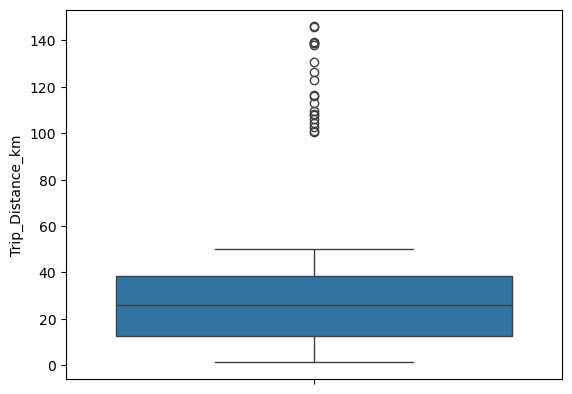

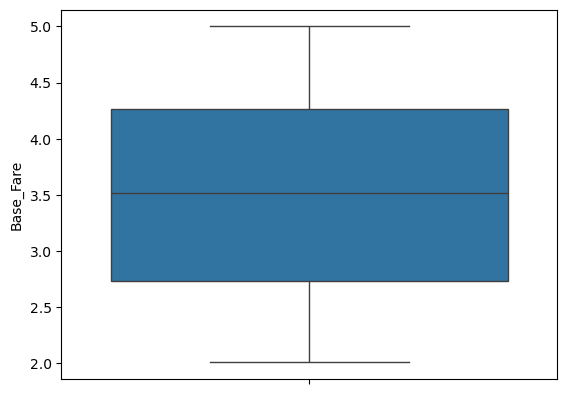

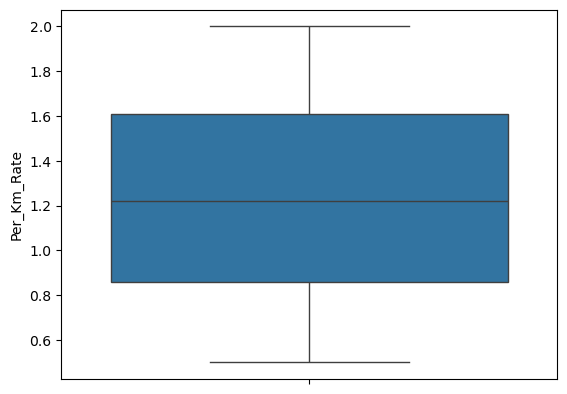

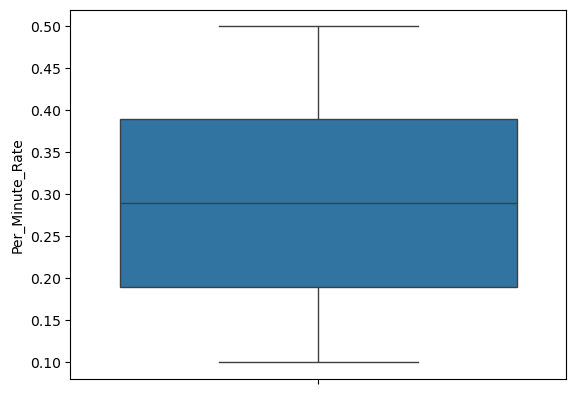

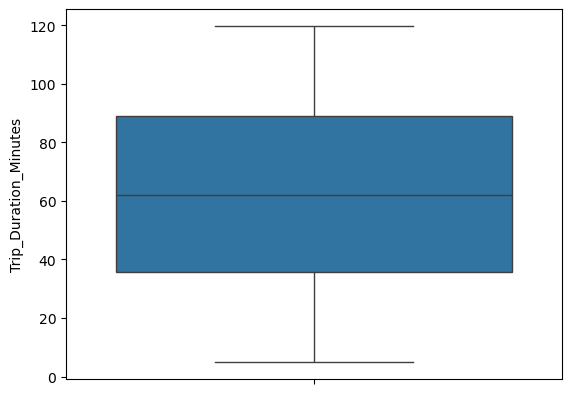

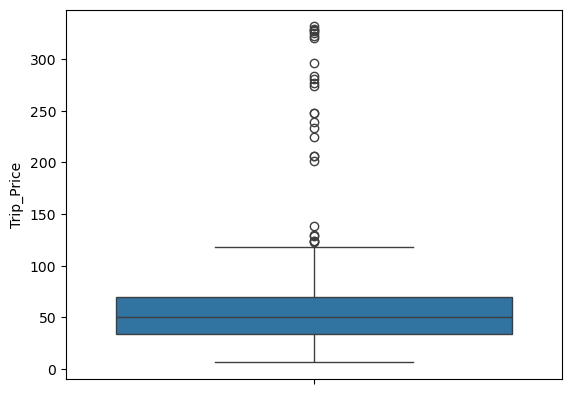

In [14]:
for i in continous:
    sns.boxplot(df[i])
    plt.show()

- Trip price and trip distance contains outliers

In [15]:
# check whether any wrong values entered 

df[(df['Trip_Distance_km'] > df['Trip_Distance_km'].max()) | (df['Trip_Distance_km'] < df['Trip_Distance_km'].min())]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price


In [16]:
df[(df['Trip_Price'] > df['Trip_Price'].max()) | (df['Trip_Price'] < df['Trip_Price'].min())]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price


- All values in range

**Check distribution of continous data**

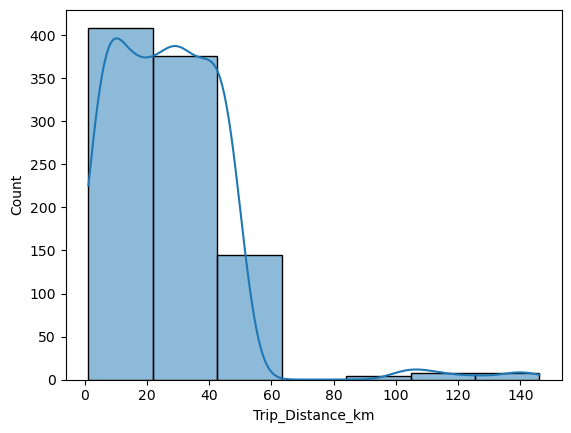

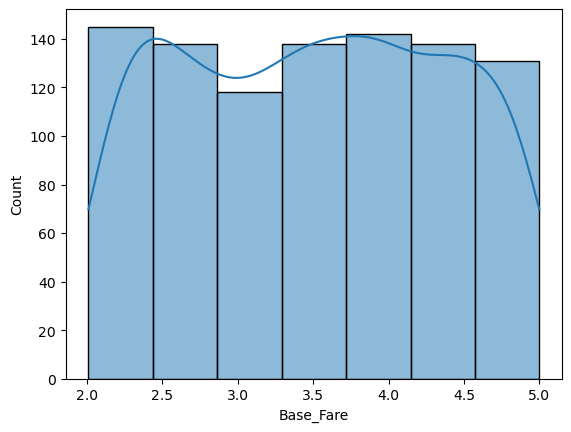

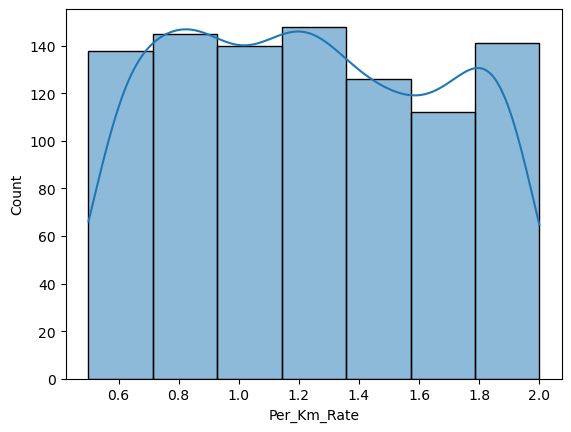

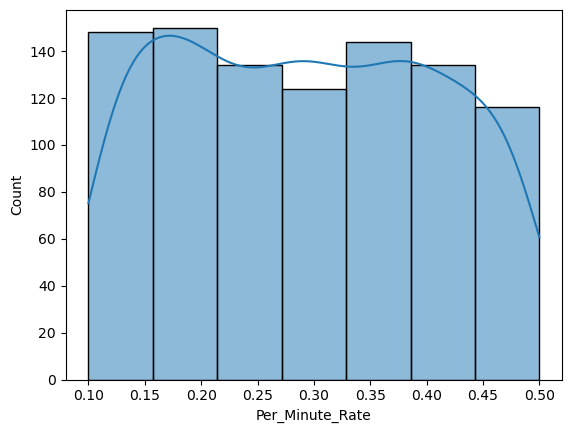

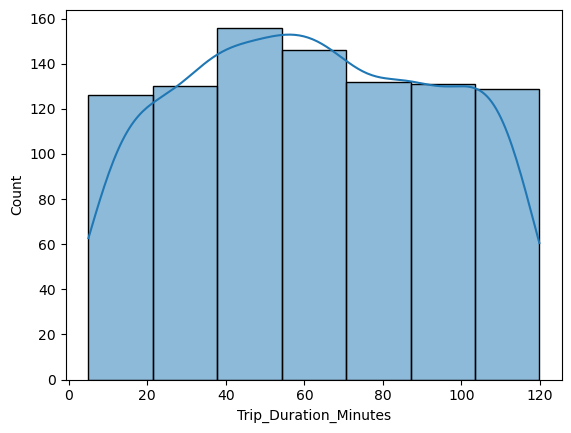

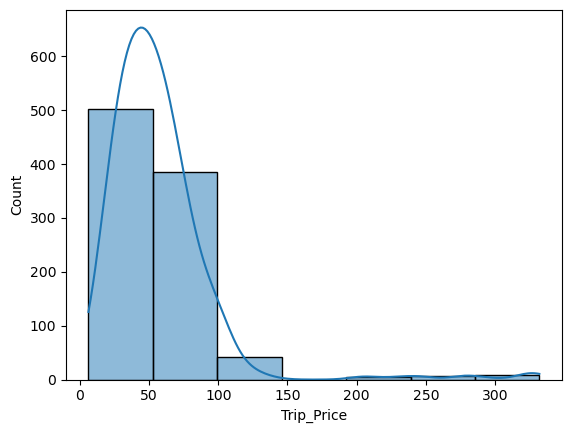

In [17]:
for i in continous:
    sns.histplot(df[i], bins= 7, kde=True)
    plt.show()

- Trip_Distance_km is right skewed it input variable i will apply transformation for normal distributon
- Trip_price is right skewed but its a output variable so dont touch it

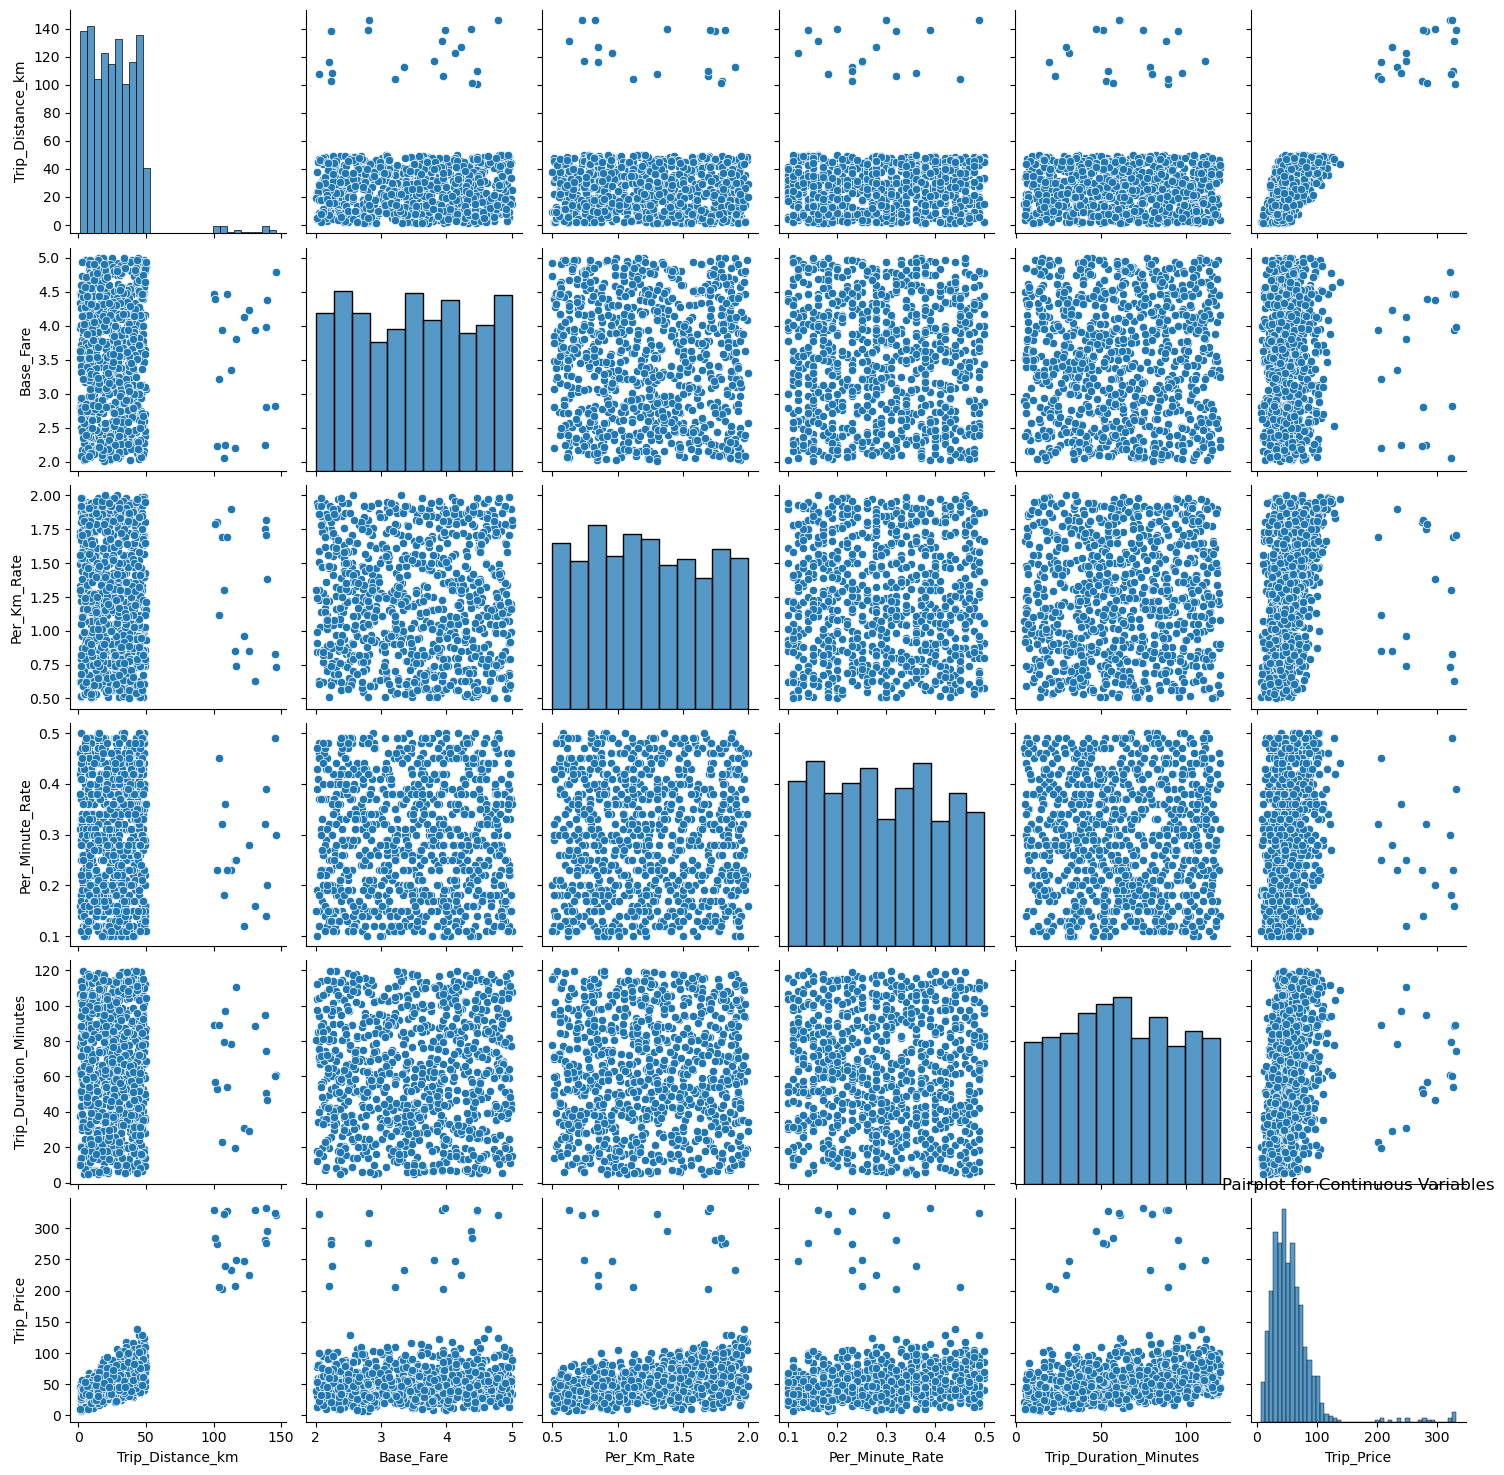

In [18]:
# Apply pairplot
sns.pairplot(df[continous])
plt.title("Pairplot for Continuous Variables")
plt.show()

**Distribution of discrete_count**

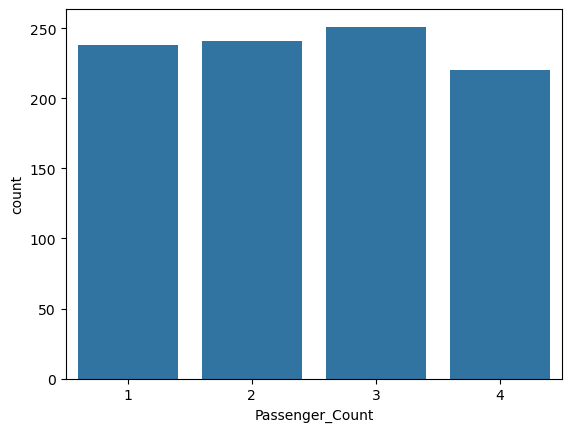

In [19]:
sns.countplot(x = df['Passenger_Count'])
plt.show()

- mostly 3 passenger booked taxi

In [20]:
# check value count for categorical

In [21]:
for i in discrete_categorical:
    print(i , " : ", df[i].value_counts())
    print("==============================")

Time_of_Day  :  Time_of_Day
Afternoon    371
Morning      283
Evening      203
Night         93
Name: count, dtype: int64
Day_of_Week  :  Day_of_Week
Weekday    655
Weekend    295
Name: count, dtype: int64
Traffic_Conditions  :  Traffic_Conditions
Low       397
Medium    371
High      182
Name: count, dtype: int64
Weather  :  Weather
Clear    667
Rain     227
Snow      56
Name: count, dtype: int64


**Observation**

- Time_of_Day: The data seems to be more frequent during the daytime, especially in the afternoon. Nighttime activities or events are much rarer.

- Day_of_Week: The majority of events or activities are happening on weekdays, which might suggest that the data is more reflective of regular workdays or business hours. Weekends have a much lower frequency.

- Traffic_Conditions: Most of the data seems to indicate low to medium traffic conditions, with high traffic being less frequent. This could suggest that the majority of the observed events happen under moderate or lighter traffic conditions

- Weather: Clear weather dominates the dataset, with rain being less common and snow being quite rare. This suggests that the events or data collection likely happens more often during favorable weather conditions.